In [1]:
!pip install -q kagglehub

In [2]:
import kagglehub
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

In [3]:
dataset_path = kagglehub.dataset_download(
    "sovitrath/diabetic-retinopathy-224x224-gaussian-filtered"
)

print(dataset_path)

Using Colab cache for faster access to the 'diabetic-retinopathy-224x224-gaussian-filtered' dataset.
/kaggle/input/diabetic-retinopathy-224x224-gaussian-filtered


In [4]:
for root, dirs, files in os.walk(dataset_path):
    print(root)
    print("Folders:", dirs)
    print("Files:", len(files))
    print("-"*50)

/kaggle/input/diabetic-retinopathy-224x224-gaussian-filtered
Folders: ['gaussian_filtered_images']
Files: 1
--------------------------------------------------
/kaggle/input/diabetic-retinopathy-224x224-gaussian-filtered/gaussian_filtered_images
Folders: ['gaussian_filtered_images']
Files: 0
--------------------------------------------------
/kaggle/input/diabetic-retinopathy-224x224-gaussian-filtered/gaussian_filtered_images/gaussian_filtered_images
Folders: ['Mild', 'Proliferate_DR', 'Moderate', 'No_DR', 'Severe']
Files: 1
--------------------------------------------------
/kaggle/input/diabetic-retinopathy-224x224-gaussian-filtered/gaussian_filtered_images/gaussian_filtered_images/Mild
Folders: []
Files: 370
--------------------------------------------------
/kaggle/input/diabetic-retinopathy-224x224-gaussian-filtered/gaussian_filtered_images/gaussian_filtered_images/Proliferate_DR
Folders: []
Files: 295
--------------------------------------------------
/kaggle/input/diabetic-retino

In [5]:
train_path = os.path.join(dataset_path, "gaussian_filtered_images", "gaussian_filtered_images")

# Get all entries in the train_path
all_entries = os.listdir(train_path)

# Filter to include only directories (which are your class folders)
classes = [entry for entry in all_entries if os.path.isdir(os.path.join(train_path, entry))]

for c in classes:
    total = len(os.listdir(os.path.join(train_path, c)))
    print(f"{c}: {total} images")

Mild: 370 images
Proliferate_DR: 295 images
Moderate: 999 images
No_DR: 1805 images
Severe: 193 images


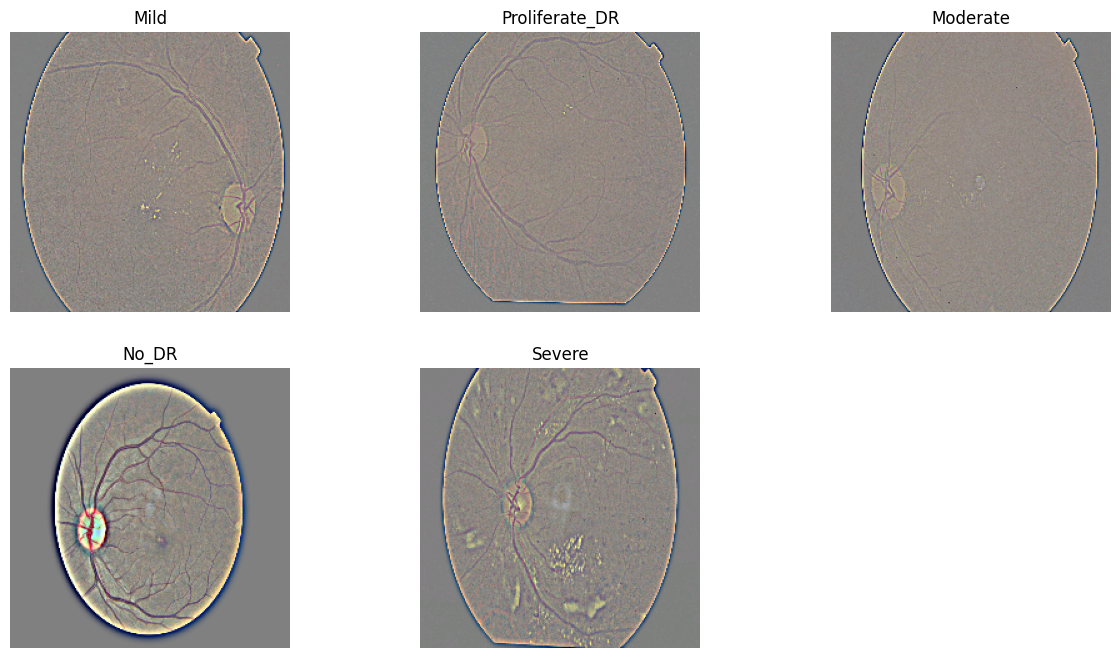

In [6]:
import cv2

plt.figure(figsize=(15,8))

for i, cls in enumerate(classes):

    img_name = os.listdir(os.path.join(train_path, cls))[0]

    img = cv2.imread(
        os.path.join(train_path, cls, img_name)
    )

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

In [7]:
IMG_SIZE = (224,224)

# Define a validation split ratio
VALIDATION_SPLIT = 0.2
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMG_SIZE,
    batch_size=32,
    label_mode="categorical",
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED
)

Found 3662 files belonging to 5 classes.
Using 2930 files for training.


In [8]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_path, # Use train_path as the base for validation as well
    image_size=IMG_SIZE,
    batch_size=32,
    label_mode="categorical",
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED
)

Found 3662 files belonging to 5 classes.
Using 732 files for validation.


### Building the Deep Learning Model

We will create a Convolutional Neural Network (CNN) using `tf.keras.Sequential` API. A typical CNN architecture for image classification includes:

*   **Convolutional Layers (`Conv2D`)**: These layers learn local patterns in the images.
*   **Activation Functions (e.g., `ReLU`)**: Introduce non-linearity to the model.
*   **Pooling Layers (`MaxPooling2D`)**: Reduce the spatial dimensions of the output volume, which helps to reduce the number of parameters and computational cost, and control overfitting.
*   **Flatten Layer**: Converts the 2D feature maps into a 1D vector.
*   **Dense (Fully Connected) Layers**: These layers perform classification based on the features extracted by the convolutional layers.
*   **Dropout Layer**: A regularization technique to prevent overfitting by randomly setting a fraction of input units to 0 at each update during training time.

Since we have 5 classes, the final `Dense` layer will have 5 units with a `softmax` activation function for multi-class classification.

In [9]:
num_classes = len(classes) # Get the number of classes dynamically

model = tf.keras.Sequential([
    # Removed data augmentation layers as they are for training and cause issues with TFSMLayer for inference

    # Convolutional layers - explicitly define input shape in the first Conv2D layer
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Flatten layer
    tf.keras.layers.Flatten(),

    # Dense layers
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5), # Dropout for regularization
    tf.keras.layers.Dense(num_classes, activation='softmax') # Output layer for 5 classes
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,245,957 (84.86 MB)

 Trainable params: 22,245,957 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
num_classes = len(classes) # Get the number of classes dynamically

model = tf.keras.Sequential([
    # Removed data augmentation layers as they are for training and cause issues with TFSMLayer for inference

    # Convolutional layers - explicitly define input shape in the first Conv2D layer
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Flatten layer
    tf.keras.layers.Flatten(),

    # Dense layers
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5), # Dropout for regularization
    tf.keras.layers.Dense(num_classes, activation='softmax') # Output layer for 5 classes
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,245,957 (84.86 MB)

 Trainable params: 22,245,957 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

### Compiling the Model

After defining the model architecture, we need to compile it. This involves specifying:

*   **Optimizer**: The algorithm used to update the weights during training (e.g., `Adam`).
*   **Loss Function**: A measure of how well the model performs (e.g., `categorical_crossentropy` for multi-class classification with one-hot encoded labels).
*   **Metrics**: Used to evaluate the model's performance during training and testing (e.g., `accuracy`).

In [11]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### Training the Model

Now, we'll train the model using the `train_ds` and evaluate its performance on the `val_ds`. We'll specify the number of epochs, which is the number of times the model will iterate over the entire training dataset.

In [12]:
EPOCHS = 15 # You can adjust this number

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 27s 194ms/step - accuracy: 0.6382 - loss: 23.5112 - val_accuracy: 0.6940 - val_loss: 0.8606
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.6887 - loss: 0.8912 - val_accuracy: 0.6557 - val_loss: 1.6282
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - accuracy: 0.6785 - loss: 0.9344 - val_accuracy: 0.6913 - val_loss: 0.8112
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - accuracy: 0.6918 - loss: 0.8448 - val_accuracy: 0.6981 - val_loss: 0.8204
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.6444 - loss: 0.9769 - val_accuracy: 0.3525 - val_loss: 1.3785
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.6253 - loss: 1.0103 - val_accuracy: 0.6858 - val_loss: 0.9115
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.6724 - loss: 0.9228 - val_accuracy: 0.6790 - val_loss: 0.8500
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - accuracy: 0.6765 - loss: 0.8852 - val_accuracy: 0.683

### Visualizing Training History

It's good practice to visualize the training and validation accuracy and loss over epochs to monitor the model's learning process and detect potential overfitting or underfitting.

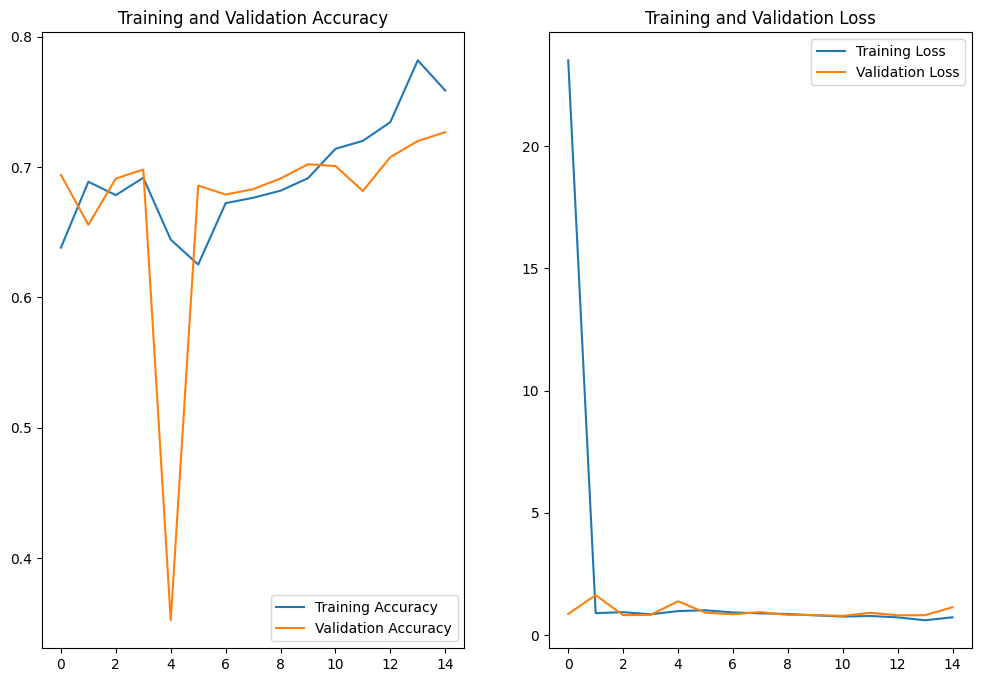

In [13]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

### Learning Rate Scheduler

To improve the training stability and potentially achieve better convergence, we'll implement a learning rate scheduler. The `ReduceLROnPlateau` callback will monitor the validation loss and reduce the learning rate if it doesn't improve after a certain number of epochs.

In [14]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',  # Monitor validation loss
    factor=0.2,          # Reduce learning rate by a factor of 0.2
    patience=3,          # Number of epochs with no improvement after which learning rate will be reduced
    min_lr=0.00001,      # Lower bound on the learning rate
    verbose=1
)

Now, let's re-train the model with this learning rate scheduler.

In [15]:
# Re-train the model with the learning rate scheduler
EPOCHS = 15 # You can adjust this number

history_with_lr_scheduler = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[reduce_lr] # Add the learning rate callback here
)

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.7887 - loss: 0.5842 - val_accuracy: 0.7090 - val_loss: 0.8777 - learning_rate: 0.0010
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.8201 - loss: 0.4889 - val_accuracy: 0.7049 - val_loss: 1.1256 - learning_rate: 0.0010
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.8430 - loss: 0.4378 - val_accuracy: 0.6940 - val_loss: 1.0599 - learning_rate: 0.0010
Epoch 4/15
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8625 - loss: 0.3871
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.8744 - loss: 0.3696 - val_accuracy: 0.7008 - val_loss: 1.1400 - learning_rate: 0.0010
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.8966 - loss: 0.2975 - val_accuracy: 0.7077 - val_loss: 1.1218 - learning_rate: 2.0000e-04
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - accuracy: 0.8966 - loss: 0.2788 - va

In [16]:
model.export('./diabetic_retinopathy_model')

Saved artifact at './diabetic_retinopathy_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_11')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  136786100647696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136786100642512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136786100648656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136786100639440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136786100646928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136786100649808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136786100647504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136786100646160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136786100649424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136786100634448: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [17]:
!ls -F

diabetic_retinopathy_model/  sample_data/


In [18]:
!ls -F diabetic_retinopathy_model

assets/  fingerprint.pb  saved_model.pb  variables/


### Visualizing Training History with Learning Rate Scheduler

Let's plot the training and validation accuracy and loss from the re-trained model to observe the effect of the learning rate scheduler.

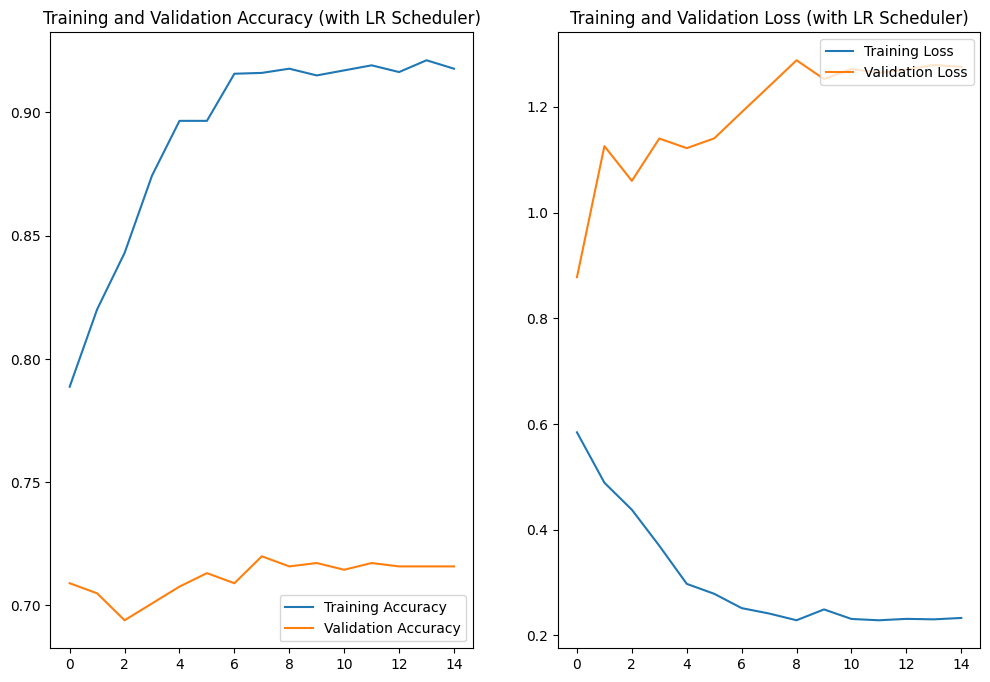

In [19]:
acc = history_with_lr_scheduler.history['accuracy']
val_acc = history_with_lr_scheduler.history['val_accuracy']

loss = history_with_lr_scheduler.history['loss']
val_loss = history_with_lr_scheduler.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy (with LR Scheduler)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss (with LR Scheduler)')
plt.show()

### Creating the Streamlit Application File (`app.py`)

This script will load your saved model, allow users to upload images, preprocess them, make predictions, and display the results. We will use `%%writefile` to save this content to a file named `app.py`.

In [20]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
from PIL import Image
import numpy as np
import os
import pandas as pd

# --- Configuration ---
IMG_SIZE = (224, 224)
CLASSES = ['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']

# --- Load the Model ---
# Removed @st.cache_resource to ensure the latest model is always loaded
def load_model_for_inference(model_path, img_size):
    try:
        tfsm_layer = tf.keras.layers.TFSMLayer(model_path, call_endpoint='serving_default')

        inference_model = tf.keras.Sequential([
            tf.keras.Input(shape=(img_size[0], img_size[1], 3)),
            tfsm_layer
        ])
        return inference_model
    except Exception as e:
        st.error(f"Error loading model: {e}")
        return None

# Use absolute path for robustness
model_path = '/content/diabetic_retinopathy_model'
model = load_model_for_inference(model_path, IMG_SIZE)

# --- Streamlit UI ---
st.title("Diabetic Retinopathy Classification")
st.write("Upload an image of a retina to classify the severity of Diabetic Retinopathy.")

if model is None:
    st.stop()

uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    image = Image.open(uploaded_file)
    st.image(image, caption='Uploaded Image', use_column_width=True)
    st.write("")

    img_array = np.array(image.resize(IMG_SIZE))
    if img_array.ndim == 2:
        img_array = np.stack((img_array,)*3, axis=-1)
    elif img_array.shape[2] == 4:
        img_array = img_array[:, :, :3]

    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    st.write("Classifying...")
    predictions = model.predict(img_array)

    if predictions.ndim == 1:
        predictions = np.expand_dims(predictions, axis=0)

    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_class_name = CLASSES[predicted_class_index]
    confidence = np.max(predictions) * 100

    st.success(f"Prediction: **{predicted_class_name}**")
    st.write(f"Confidence: {confidence:.2f}%")

    st.subheader("All Class Probabilities:")
    prediction_df = pd.DataFrame({
        'Class': CLASSES,
        'Probability': predictions[0] * 100
    })
    st.dataframe(prediction_df.sort_values(by='Probability', ascending=False).round(2).astype(str) + '%')

Writing app.py


### Instructions to run the Streamlit Application

To run your Streamlit app in Colab, you'll need `ngrok` to expose the local Streamlit server to the internet.

**Important:** Ensure you have your `NGROK_AUTH_TOKEN` set up in Colab secrets (under the 🔑 icon in the left panel). If you don't have one, you can get it from [ngrok.com](https://ngrok.com/).

Execute the following cells to install `pyngrok` and then run your Streamlit app.

In [21]:
!pip install -q pyngrok

In [22]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 85.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 118.1 MB/s eta 0:00:00


In [23]:
from pyngrok import ngrok
ngrok.set_auth_token("3AbwaW53yv021tNxAXrWJumLaDB_7ooi3CHcXxwCCt7XaTCXX")

In [24]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://foraminate-anders-uncovetous.ngrok-free.dev" -> "http://localhost:8501"


In [25]:
!cd /content && streamlit run app.py &



2026-07-19 15:18:13.804 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.16.199.70:8501

2026-07-19 15:18:39.697010: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1784474319.698557    2579 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11585 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
2026-07-19 15:18:47.168 The `use_column_width` parameter has been deprecated and will be removed in a future release. Please utilize the `width` parameter instead.
I0000 00:00:1784474328.278149    2615 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
1/1 ━━━━━━

### Compiling the Model

After defining the model architecture, we need to compile it. This involves specifying:

*   **Optimizer**: The algorithm used to update the weights during training (e.g., `Adam`).
*   **Loss Function**: A measure of how well the model performs (e.g., `categorical_crossentropy` for multi-class classification with one-hot encoded labels).
*   **Metrics**: Used to evaluate the model's performance during training and testing (e.g., `accuracy`).

In [26]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### Training the Model

Now, we'll train the model using the `train_ds` and evaluate its performance on the `val_ds`. We'll specify the number of epochs, which is the number of times the model will iterate over the entire training dataset.

In [27]:
EPOCHS = 15 # You can adjust this number

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 95ms/step - accuracy: 0.8683 - loss: 0.3861 - val_accuracy: 0.7036 - val_loss: 1.4253
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.8754 - loss: 0.3594 - val_accuracy: 0.7008 - val_loss: 1.3467
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.8928 - loss: 0.3239 - val_accuracy: 0.6995 - val_loss: 1.5365
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.8962 - loss: 0.2877 - val_accuracy: 0.6995 - val_loss: 1.2900
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - accuracy: 0.9174 - loss: 0.2522 - val_accuracy: 0.6844 - val_loss: 1.4873
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.9181 - loss: 0.2254 - val_accuracy: 0.6940 - val_loss: 1.5518
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step - accuracy: 0.9300 - loss: 0.2095 - val_accuracy: 0.6885 - val_loss: 1.7636
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - accuracy: 0.9215 - loss: 0.2261 - val_accuracy: 0.6926

### Visualizing Training History

It's good practice to visualize the training and validation accuracy and loss over epochs to monitor the model's learning process and detect potential overfitting or underfitting.

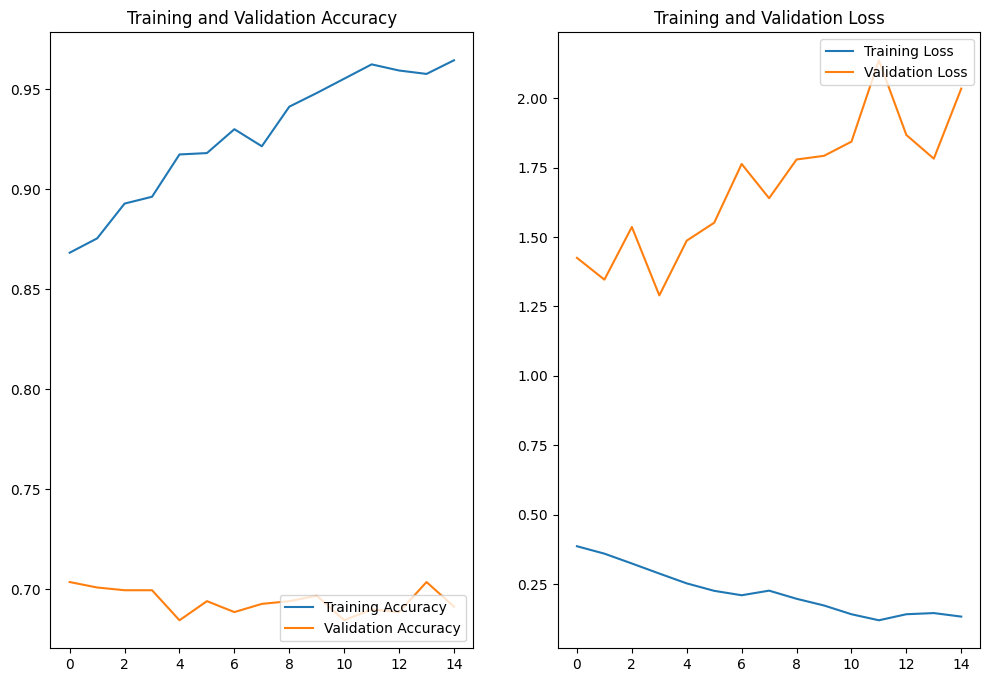

In [28]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

### Learning Rate Scheduler

To improve the training stability and potentially achieve better convergence, we'll implement a learning rate scheduler. The `ReduceLROnPlateau` callback will monitor the validation loss and reduce the learning rate if it doesn't improve after a certain number of epochs.

In [29]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',  # Monitor validation loss
    factor=0.2,          # Reduce learning rate by a factor of 0.2
    patience=3,          # Number of epochs with no improvement after which learning rate will be reduced
    min_lr=0.00001,      # Lower bound on the learning rate
    verbose=1
)


Now, let's re-train the model with this learning rate scheduler.

In [30]:
# Re-train the model with the learning rate scheduler
EPOCHS = 15 # You can adjust this number

history_with_lr_scheduler = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[reduce_lr] # Add the learning rate callback here
)


Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 115ms/step - accuracy: 0.9720 - loss: 0.1105 - val_accuracy: 0.6954 - val_loss: 2.1838 - learning_rate: 0.0010
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.9700 - loss: 0.1026 - val_accuracy: 0.6981 - val_loss: 1.8624 - learning_rate: 0.0010
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.9662 - loss: 0.1260 - val_accuracy: 0.6872 - val_loss: 1.8863 - learning_rate: 0.0010
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.9686 - loss: 0.1095 - val_accuracy: 0.6995 - val_loss: 2.4510 - learning_rate: 0.0010
Epoch 5/15
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9678 - loss: 0.1689
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9706 - loss: 0.1140 - val_accuracy: 0.6940 - val_loss: 2.7833 - learning_rate: 0.0010
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.9751 - loss: 0.0835 - val_a

In [31]:
model.export('./diabetic_retinopathy_model')

Saved artifact at './diabetic_retinopathy_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_11')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  136786100647696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136786100642512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136786100648656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136786100639440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136786100646928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136786100649808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136786100647504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136786100646160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136786100649424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136786100634448: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [32]:
!ls -F

app.py	diabetic_retinopathy_model/  sample_data/


In [33]:
!ls -F diabetic_retinopathy_model

assets/  fingerprint.pb  saved_model.pb  variables/


### Visualizing Training History with Learning Rate Scheduler

Let's plot the training and validation accuracy and loss from the re-trained model to observe the effect of the learning rate scheduler.

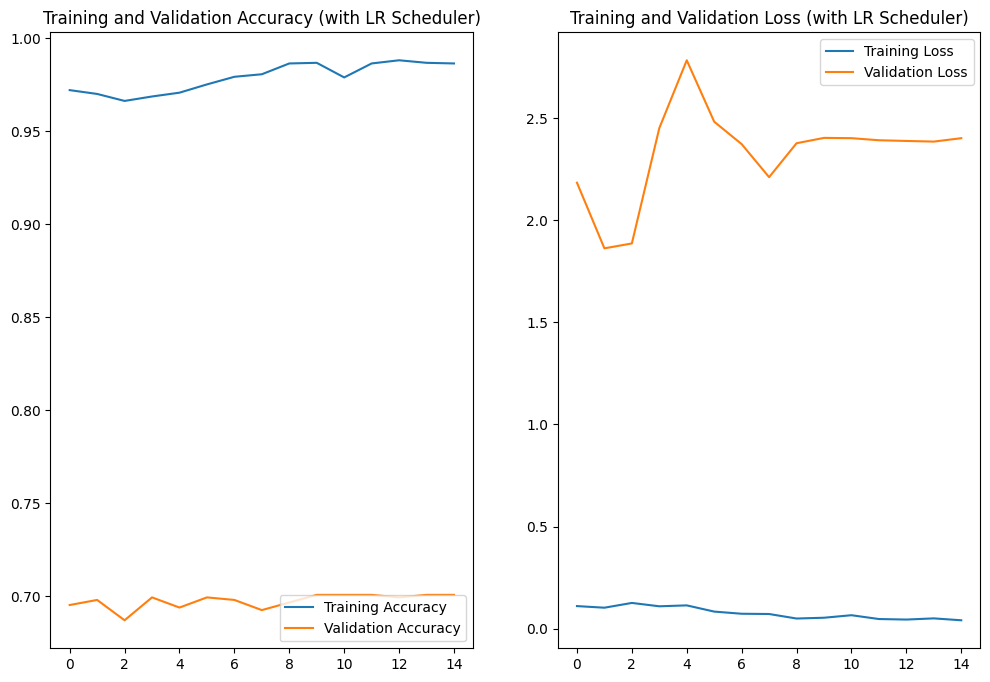

In [34]:
acc = history_with_lr_scheduler.history['accuracy']
val_acc = history_with_lr_scheduler.history['val_accuracy']

loss = history_with_lr_scheduler.history['loss']
val_loss = history_with_lr_scheduler.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy (with LR Scheduler)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss (with LR Scheduler)')
plt.show()


### Creating the Streamlit Application File (`app.py`)

This script will load your saved model, allow users to upload images, preprocess them, make predictions, and display the results. We will use `%%writefile` to save this content to a file named `app.py`.

In [44]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
from PIL import Image
import numpy as np
import os
import pandas as pd

# --- Configuration ---
IMG_SIZE = (224, 224)
CLASSES = ['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']

# --- Load the Model ---
# Removed @st.cache_resource to ensure the latest model is always loaded
def load_model_for_inference(model_path, img_size):
    try:
        tfsm_layer = tf.keras.layers.TFSMLayer(model_path, call_endpoint='serving_default')

        inference_model = tf.keras.Sequential([
            tf.keras.Input(shape=(img_size[0], img_size[1], 3)),
            tfsm_layer
        ])
        return inference_model
    except Exception as e:
        st.error(f"Error loading model: {e}")
        return None

# Use absolute path for robustness
model_path = '/content/diabetic_retinopathy_model'
model = load_model_for_inference(model_path, IMG_SIZE)

# --- Streamlit UI ---
st.title("Diabetic Retinopathy Classification")
st.write("Upload an image of a retina to classify the severity of Diabetic Retinopathy.")

if model is None:
    st.stop()

uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    image = Image.open(uploaded_file)
    st.image(image, caption='Uploaded Image', use_column_width=True)
    st.write("")

    img_array = np.array(image.resize(IMG_SIZE))
    if img_array.ndim == 2:
        img_array = np.stack((img_array,)*3, axis=-1)
    elif img_array.shape[2] == 4:
        img_array = img_array[:, :, :3]

    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    st.write("Classifying...")
    raw_predictions = model.predict(img_array)

    # Debugging: Print raw predictions type and content
    st.write(f"Debug: Type of raw_predictions: {type(raw_predictions)}")
    st.write(f"Debug: raw_predictions content: {raw_predictions}")

    # Helper function to recursively find the first tf.Tensor or np.ndarray
    def find_tensor_or_array(obj):
        if isinstance(obj, (tf.Tensor, np.ndarray)):
            return obj
        if isinstance(obj, dict):
            for value in obj.values():
                result = find_tensor_or_array(value)
                if result is not None:
                    return result
        if isinstance(obj, list):
            for item in obj:
                result = find_tensor_or_array(item)
                if result is not None:
                    return result
        return None

    predictions = find_tensor_or_array(raw_predictions)

    if predictions is None:
        st.error("Could not extract a prediction tensor/array from model output. Unexpected model output format.")
        st.stop()

    # Debugging: Print predictions type and content after extraction
    st.write(f"Debug: Type of predictions after extraction: {type(predictions)}")
    st.write(f"Debug: predictions content after extraction: {predictions}")

    # Ensure predictions is a NumPy array for consistent operations like .ndim
    if isinstance(predictions, tf.Tensor):
        predictions = predictions.numpy()

    # Original check for ndim now should work correctly
    if predictions.ndim == 1:
        predictions = np.expand_dims(predictions, axis=0)

    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_class_name = CLASSES[predicted_class_index]
    confidence = np.max(predictions) * 100

    st.success(f"Prediction: **{predicted_class_name}**")
    st.write(f"Confidence: {confidence:.2f}%")

    st.subheader("All Class Probabilities:")
    prediction_df = pd.DataFrame({
        'Class': CLASSES,
        'Probability': predictions[0] * 100
    })
    st.dataframe(prediction_df.sort_values(by='Probability', ascending=False).round(2).astype(str) + '%')

Overwriting app.py


In [37]:
!cd /content && streamlit run app.py &



2026-07-19 15:24:19.020 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.16.199.70:8501

  Stopping...


### Instructions to run the Streamlit Application

To run your Streamlit app in Colab, you'll need `ngrok` to expose the local Streamlit server to the internet.

**Important:** Ensure you have your `NGROK_AUTH_TOKEN` set up in Colab secrets (under the 🔑 icon in the left panel). If you don't have one, you can get it from [ngrok.com](https://ngrok.com/).

Execute the following cells to install `pyngrok` and then run your Streamlit app.

In [38]:
!pip install -q pyngrok

In [39]:
!pip install -q streamlit

In [40]:
from pyngrok import ngrok
ngrok.set_auth_token("3AbwaW53yv021tNxAXrWJumLaDB_7ooi3CHcXxwCCt7XaTCXX")

In [47]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://foraminate-anders-uncovetous.ngrok-free.dev" -> "http://localhost:8501"


In [49]:
!cd /content && streamlit run app.py &



2026-07-19 15:28:07.000 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.16.199.70:8501

2026-07-19 15:28:16.540832: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1784474896.542354    5872 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11585 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
2026-07-19 15:28:34.561 The `use_column_width` parameter has been deprecated and will be removed in a future release. Please utilize the `width` parameter instead.
I0000 00:00:1784474915.593841    5913 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
1/1 ━━━━━━

In [48]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://foraminate-anders-uncovetous.ngrok-free.dev" -> "http://localhost:8501"
